# Bitcoin cycles

Bitcoin prices in relation to halving cycles.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

from dotenv import load_dotenv

from btc_cycles import Bitcoin

load_dotenv()

False

## Bitcoin

`Bitcoin` is the main object.
Fetches data from the selected source, computes metrics (ATH, cycle progress, and cycle lows).

*Available sources*:
- `cryptocompare` (**default**): [cryptocompare](https://www.cryptocompare.com/) — free-tier API key
- `coinmarketcap-free`: [coinmarketcap](https://coinmarketcap.com/) — **broken legacy API** ([see here](https://github.com/guptarohit/cryptoCMD/issues/86))

*Arguments*
- `source` (str) : data source. Defaults to `"cryptocompare"`.
- `currency` (str) : currency. Defaults to `"USD"`.
- `api_key` (str | None) : API key for the data source.

*Attributes*
- `prices` (pd.DataFrame) : prices with cycle metrics
- `halvings` (pd.DataFrame) : halving dates and cycle info
- `predicted_halving_block` (int) : block of next halving
- `predicted_halving_date` (datetime) : predicted date of next halving

In [3]:
btc = Bitcoin(
    source="cryptocompare",
    api_key=os.getenv("CRYPTOCOMPARE_API_KEY"),
)

In [4]:
print(
    f"Next halving (block {btc.predicted_halving_block}) "
    f"is predicted on {btc.predicted_halving_date}"
)

Next halving (block 1050000) is predicted on 2028-04-10 21:58:47+00:00


In [5]:
btc.halvings.head(10)

,block,reward,Date,cycle_length,cycle_id
0,0,50,2009-01-03 00:00:00+00:00,1425.0,1
1,210000,25.0,2012-11-28 00:00:00+00:00,1319.0,2
2,420000,12.5,2016-07-09 00:00:00+00:00,1402.0,3
3,630000,6.25,2020-05-11 00:00:00+00:00,1440.0,4
4,840000,3.125,2024-04-20 12:09:27+00:00,1451.0,5
5,1050000,1.5625,2028-04-10 21:58:47+00:00,NaN,6
6,1260000,0.78125,NaT,NaN,7
7,1470000,0.390625,NaT,NaN,8
8,1680000,0.195312,NaT,NaN,9
9,1890000,0.097656,NaT,NaN,10


In [6]:
btc.halvings

,block,reward,Date,cycle_length,cycle_id
0,0,50,2009-01-03 00:00:00+00:00,1425.0,1
1,210000,25.0,2012-11-28 00:00:00+00:00,1319.0,2
2,420000,12.5,2016-07-09 00:00:00+00:00,1402.0,3
3,630000,6.25,2020-05-11 00:00:00+00:00,1440.0,4
4,840000,3.125,2024-04-20 12:09:27+00:00,1451.0,5
5,1050000,1.5625,2028-04-10 21:58:47+00:00,NaN,6
6,1260000,0.78125,NaT,NaN,7
7,1470000,0.390625,NaT,NaN,8
8,1680000,0.195312,NaT,NaN,9
9,1890000,0.097656,NaT,NaN,10


In [7]:
btc.prices

,Date,Close,block,reward,cycle_length,cycle_id,Halving,ATH,distance_ath_perc,is_cycle_low,cycle_progress
0,2010-07-17 00:00:00+00:00,0.04951,0.0,50.000,1425.0,1.0,2009-01-03 00:00:00+00:00,0.04951,0.000000,False,0.392982
1,2010-07-18 00:00:00+00:00,0.08584,0.0,50.000,1425.0,1.0,2009-01-03 00:00:00+00:00,0.08584,0.000000,False,0.393684
2,2010-07-19 00:00:00+00:00,0.08080,0.0,50.000,1425.0,1.0,2009-01-03 00:00:00+00:00,0.08584,-0.058714,False,0.394386
3,2010-07-20 00:00:00+00:00,0.07474,0.0,50.000,1425.0,1.0,2009-01-03 00:00:00+00:00,0.08584,-0.129310,False,0.395088
4,2010-07-21 00:00:00+00:00,0.07921,0.0,50.000,1425.0,1.0,2009-01-03 00:00:00+00:00,0.08584,-0.077237,False,0.395789
...,...,...,...,...,...,...,...,...,...,...,...
5791,2026-05-25 00:00:00+00:00,77273.26000,840000.0,3.125,1451.0,5.0,2024-04-20 12:09:27+00:00,124723.00000,-0.380441,False,0.526533
5792,2026-05-26 00:00:00+00:00,75842.51000,840000.0,3.125,1451.0,5.0,2024-04-20 12:09:27+00:00,124723.00000,-0.391912,False,0.527223
5793,2026-05-27 00:00:00+00:00,74348.55000,840000.0,3.125,1451.0,5.0,2024-04-20 12:09:27+00:00,124723.00000,-0.403891,False,0.527912
5794,2026-05-28 00:00:00+00:00,73531.95000,840000.0,3.125,1451.0,5.0,2024-04-20 12:09:27+00:00,124723.00000,-0.410438,False,0.528601


## Plots

The method `plot` returns a chart of the prices.

Arguments:
- `kind` (str): `"static"` (matplotlib) or `"interactive"` (plotly). Default is `"static"`.
- `from_date` (str or datetime): date from which data is plotted. Some sources offers unlimited historical data and some filtering might be needed.
- `theme` (str or dict): theme of the plot. Default is `light`, or `dark` for dark mode. Custom themes can be passed as a dictionary. Colors can also be customized singularly.

### Static chart (matplotlib)

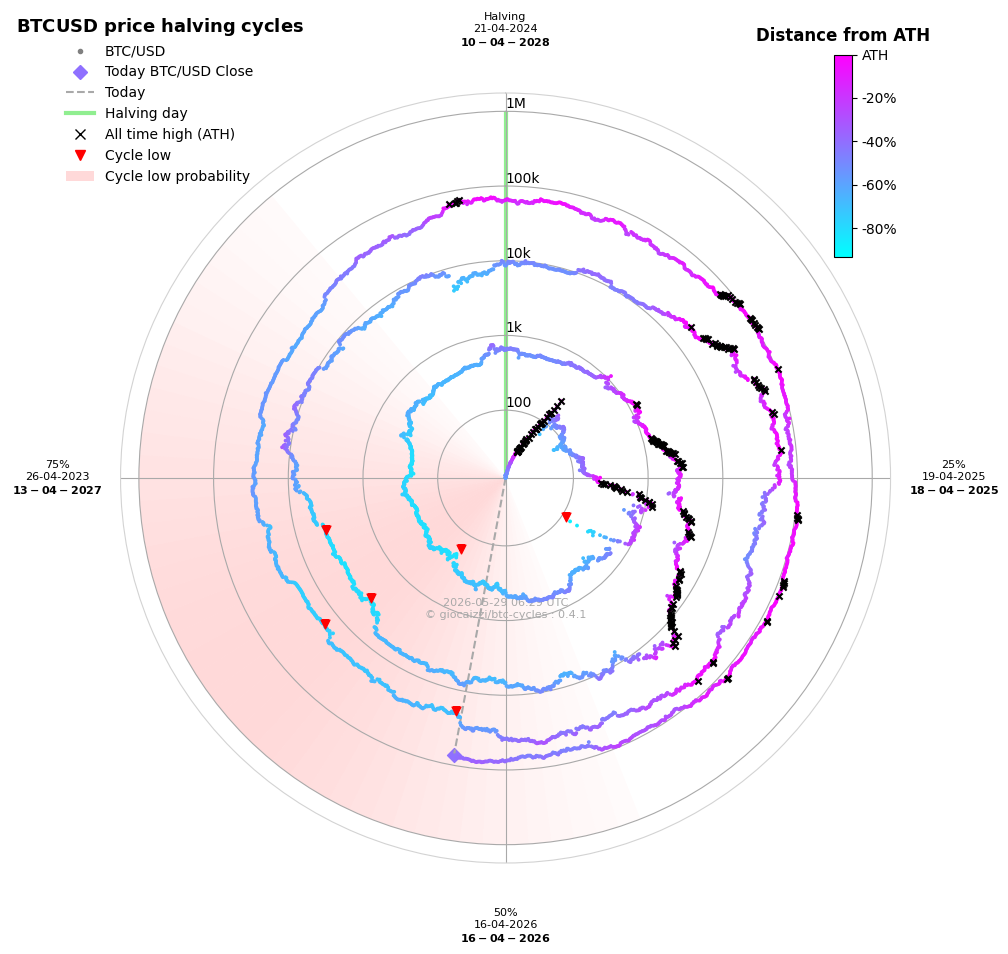

In [8]:
fig = btc.plot(
    from_date="2012-11-28",  # start date
    # theme="dark",  # dark or light, or dict with custom colors.
    # theme = {
    #     "now_line": "red"
    # },
)
# # fig is a matplotlib figure object
fig.savefig("bitcoin.png")

### Interactive chart (plotly)

In [9]:
fig_interactive = btc.plot(
    kind="interactive",
    from_date="2012-11-28",
)
# plotly config for interactivity
config = {"scrollZoom": True, "displayModeBar": True}
# display in notebook
fig_interactive.show(config=config)